In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'

In [2]:
train1 = pd.read_csv('../data/1차 전처리(센서 제거)/train1_sens_filter.csv',index_col=0)
train1.head()

,engine_id,cycle,op1,op2,op3,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [42]:
sensor_cols = ['s2', 's3', 's4', 's7', 's8','s9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

In [19]:
def plot_sensor_grid(df, engine_id, subset_name="FD001", ncols=3, save_path=None):
    """엔진 하나의 21개 센서를 사이클에 따라 그리드로 그린다.
    각 서브플롯이 독립적인 y축을 쓰기 때문에, 센서 간 스케일 차이에 관계없이
    추세(오르는지/내리는지/그대로인지)를 한눈에 비교할 수 있다.
    """
    engine = df[df["engine_id"] == engine_id]
    sensor_cols = ['s2', 's3', 's4', 's7', 's8','s9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
    nrows = -(-len(sensor_cols) // ncols)  # 올림 나눗셈

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.5 * nrows), sharex=True)
    axes = axes.flatten()

    for ax, col in zip(axes, sensor_cols):
        ax.plot(engine["cycle"], engine[col], linewidth=1, color="#4C72B0")
        ax.set_title(col, fontsize=10)
        ax.grid(True, linewidth=0.4, alpha=0.4)
        ax.tick_params(labelsize=8)
        

    for ax in axes[len(sensor_cols):]:
        ax.axis("off")

    fig.suptitle(f"{subset_name} - Engine {engine_id} - 14 sensors over cycles", fontsize=13)
    fig.supxlabel("cycle")
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        fig.savefig(save_path, dpi=110)
    return fig

### 이상치 확인

- 결측치
- 물리적으로 불가능한 값(센서 범위를 벗어난 값)

초기 RUL에서의 튀는 값은 이상치, 말기 RUL에서의 튀는 값은 열화에 영향을 주는 값일 수도 있음.

일단, 센서 1개를 사이클마다 그려보고 추세선 주변에 얼마나 흔들림이 있는지 확인해보자.


특징
- 중간중간 확 튀는 스파이크성 노이즈가 보인다. 
- 초반 100사이클까지는 추세가 거의 보이지 않는다. 이후 100-150까지 조금 오른 상태이며, 이후 175-200에서 좀 더 가파른 상승을 보인다. 그렇다면 RUL 상한을 100 이상으로 생각해볼 수 있겠다.
- 고장까지 상승 추세선이므로 해당 센서는 온도에 관련된 센서로 추측할 수 있다.


다른 센서도 확인해보자.


같은 센서2의 engine_id만 다르게 해서 확인했을 때, 해당 센서의 수명은 약 300사이클이다. 
추세선은 약 150(2분의 1)까지는 미미한 상승을 보이며, 이후 상승 곡선이 가파르다. 

4번 엔진의 경우 더 확실한 차이를 볼 수 있다. 수명은 약 180회이며, 125사이클까지는 추세가 거의 평평하다. 이후엔 상승한댜. 

-> 따라서 s2같은 경우, 수명의 2분의 1까지는 추세가 상승하거나 하락하지 않고 그대로 유지되는 것을 확인할 수 있다.

각 센서들의 노이즈 유형을 파악하기 위해서 모든 센서를 서브플롯으로 띄워보자.

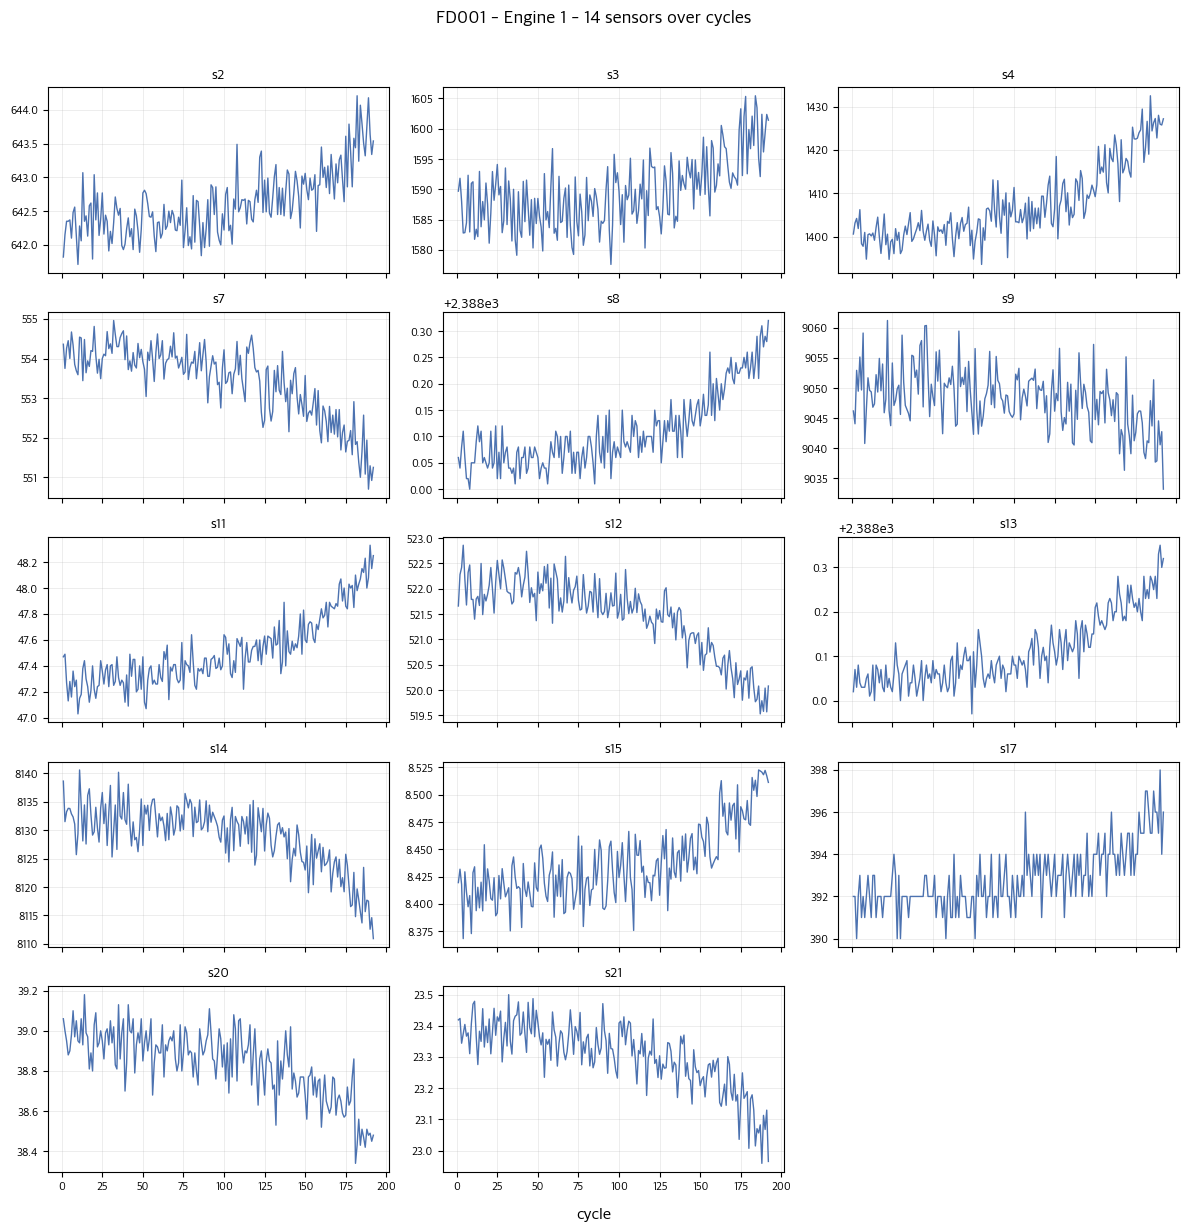

In [20]:
fig = plot_sensor_grid(train1, engine_id=1)

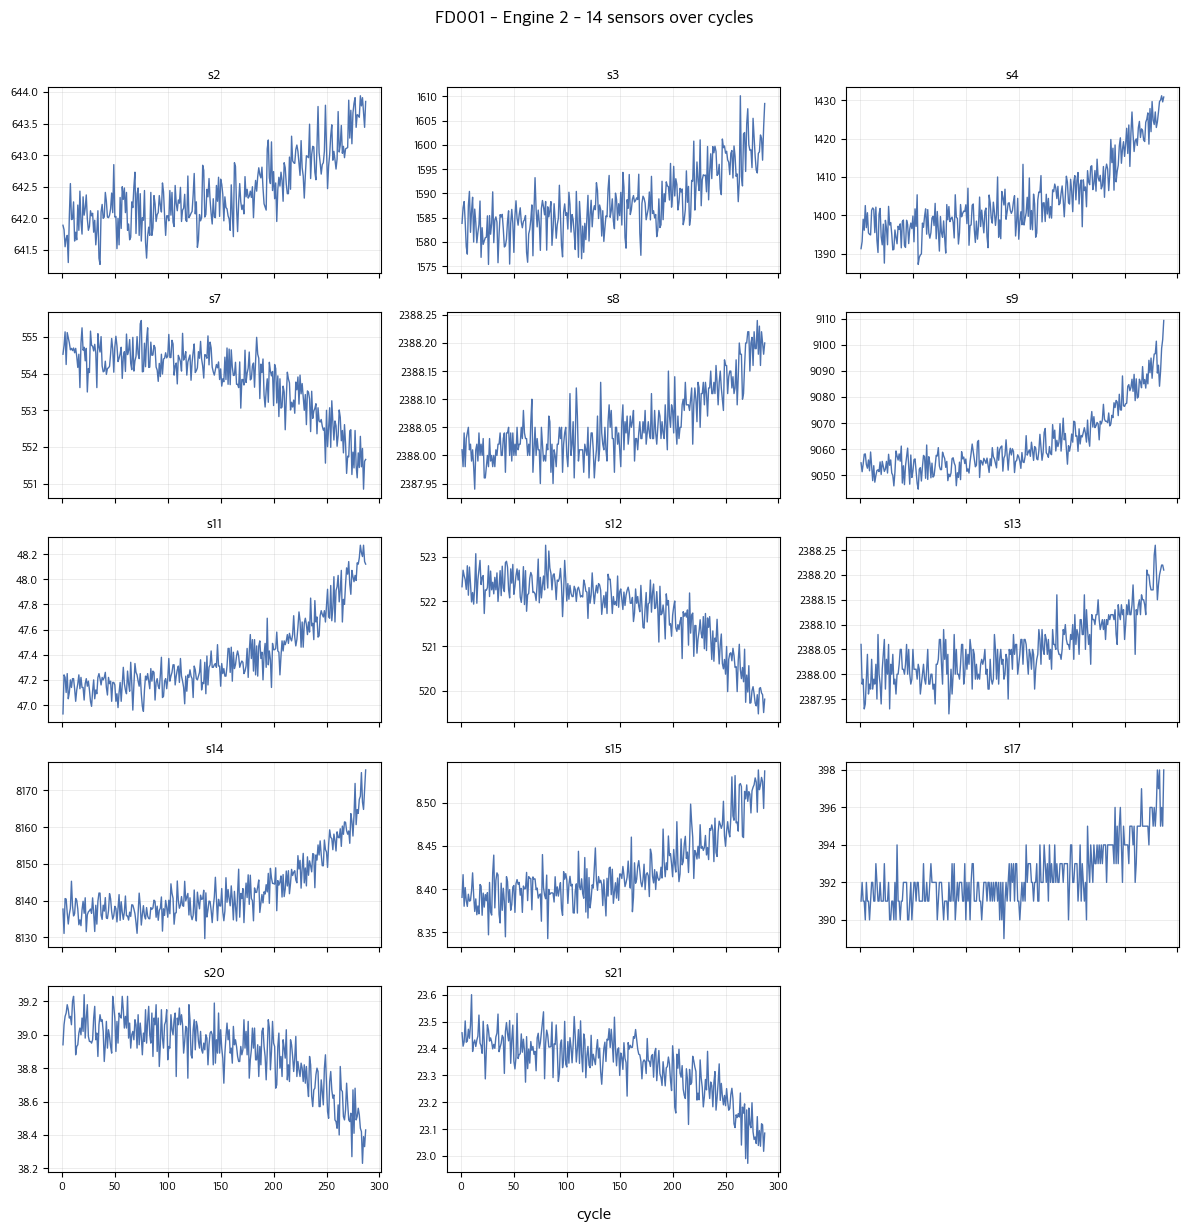

In [21]:
fig = plot_sensor_grid(train1, engine_id=2)

### 노이즈 유형 추정

- 드리프트 : 해당 데이터는 c-mapss데이터로 실제 센서가 아닌 시뮬레이터 데이터이기 때문에, 센서 자체의 노후현상까지 시뮬레이터에 포함시켰을 가능성이 낮음. 따라서 드리프트 현상은 고려하지 않음
- 양자화 노이즈 : s17에서 양자화 노이즈의 가능성이 있지만, 대부분의 센서는 양자화 노이즈(계단식)의 양상이 나타나지 않으므로 고려하지 않음. 추후에 s17만 추가적으로 진행하는 것을 고려
- 주기성 간섭 : 현재 다루고있는 FD001은 운전 조건이 한가지이므로 주기성 간섭이 생길 가능성이 매우적음. 따라서 고려하지 않음.
- 스파이크 : 14개의 센서를 그래프로 확인했을 때 가장 가능성이 높음. 실제로 정상 범위에서 벗어났다가 다시 돌아오는 수치들을 눈으로도 확인할 수 있음.



### 정규 분포인가?

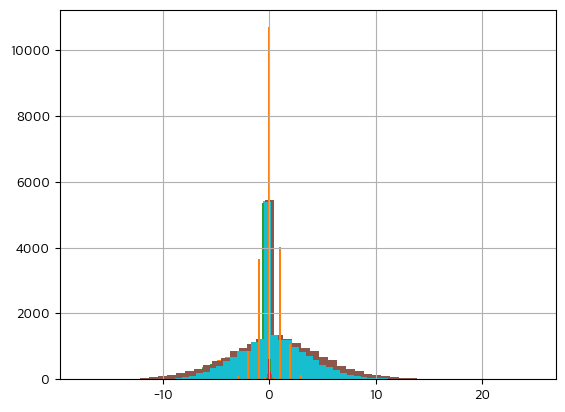

In [46]:
for col in sensor_cols:
    residual = train1.groupby("engine_id")[col].transform(
        lambda x: x - x.rolling(5, min_periods=1).median()
    )
    residual.hist(bins=50)

### 모든 센서의 분포를 확인했을 때 정규분포를 이룸

### s17같은 경우에, 계단처럼 뚝뚝 끊기는 경향이 보이기 때문에 양자화 노이즈를 추정할 수 있다. 확인해보자

In [12]:
s17_val = sorted(train1['s17'].unique())
diffs = pd.Series(s17_val).diff().dropna()
diffs.value_counts()

1.0    12
Name: count, dtype: int64

In [13]:
print('행의 개수 : ',len(train1['s17']))
print('고유값 개수 : ',train1['s17'].nunique())

행의 개수 :  20631
고유값 개수 :  13


In [14]:
print('엔진 1의 행의 개수 : ',len(train1[train1['engine_id']==1]['s17']))
print('엔진 1의 고유값의 개수 : ',train1[train1['engine_id']==1]['s17'].nunique())

엔진 1의 행의 개수 :  192
엔진 1의 고유값의 개수 :  9


In [ ]:
print('엔진 1의 행의 개수 : ',len(train1[train1['engine_id']==50]['s17']))
print('엔진 1의 고유값의 개수 : ',train1[train1['engine_id']==50]['s17'].nunique())

엔진 1의 행의 개수 :  198
엔진 1의 고유값의 개수 :  8


간격이 정확히 1로만 이루어져있기 떄문에 노이즈라기 보다는 양자화되어있는 값 자체로 봐야함.
또한 엔진 아이디를 특정하여 확인했을 때도 전체에 비해 고유값의 개수가 크게 적지 않으므로 더 데이터를 파악할 필요가 있음.

In [24]:
train1['s2']

0        641.82
1        642.15
2        642.35
3        642.35
4        642.37
          ...  
20626    643.49
20627    643.54
20628    643.42
20629    643.23
20630    643.85
Name: s2, Length: 20631, dtype: float64